<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week4/notebooks/Class4_FeatureVectorsAndEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

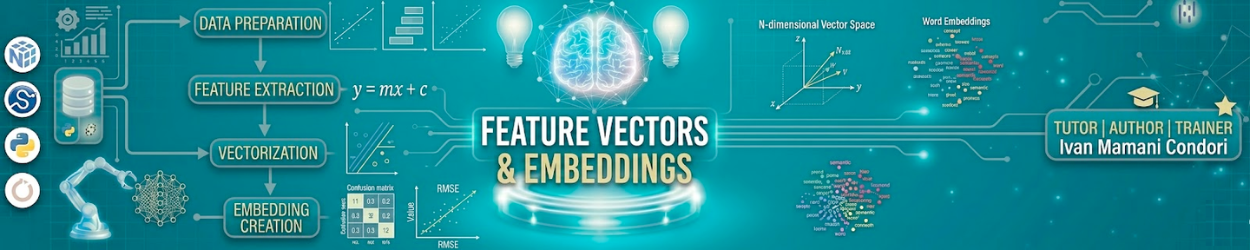

# Transfer Learning para Classificação de COVID-19 em Raios-X

**Dataset:** COVID-19 Radiography Dataset

**Fonte:** Kaggle

**Link:** https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database

**Objetivo:**

Desenvolver e comparar dois modelos de classificação supervisionada para identificar a presença de COVID-19 em imagens de raio-X do tórax.

O estudo avalia duas abordagens distintas:
- Um modelo treinado diretamente sobre os pixels das imagens (Abordagem Direta)
- Um modelo baseado em Transfer Learning utilizando a rede pré-treinada VGG16 para extração de características

A comparação é realizada considerando métricas como:
- Acurácia
- Tempo de treinamento

com foco na **qualidade da representação dos dados** e seu impacto no desempenho do modelo.

**Hipótese**

***Hipótese Nula (H0):*** O uso de Transfer Learning com VGG16 não produz melhoria significativa no desempenho da classificação de imagens de raio-X em comparação com o modelo treinado diretamente sobre os pixels brutos.

***Hipótese Alternativa (H1):*** O uso de Transfer Learning com VGG16 melhora o desempenho da classificação de imagens de raio-X em comparação com o modelo treinado diretamente sobre os pixels brutos.

**Configuração do Problema**

A variável alvo é binária:
- 0 → COVID (paciente com infecção)
- 1 → NORMAL (paciente saudável)

>Nota: Embora o dataset contenha múltiplas classes (COVID, Normal, Viral Pneumonia, Lung Opacity), neste experimento utilizamos apenas duas classes para simplificar a análise e focar na comparação metodológica.

**Contexto Científico**

Imagens de raio-X do tórax capturam padrões estruturais dos pulmões, como opacidades, inflamações e alterações no tecido pulmonar.

O desafio consiste em identificar automaticamente padrões visuais associados à presença de COVID-19, auxiliando sistemas de diagnóstico assistido por computador.

**Abordagem**

O experimento consiste na comparação entre dois classificadores:

***Classificador A — Abordagem Direta***
- Utiliza imagens redimensionadas (224x224)
- Mantém as imagens em escala de cinza
- Converte cada imagem em um vetor (flatten)
- Treina um modelo de Regressão Logística diretamente sobre os pixels

Limitação: não considera a estrutura espacial da imagem

***Classificador B — Transfer Learning***
- Utiliza a rede pré-treinada VGG16 (treinada no ImageNet)
- Converte imagens para RGB (3 canais)
- Extrai features (embeddings) das imagens
- Treina o mesmo modelo (Regressão Logística) sobre essas features

Vantagem: utiliza representações mais ricas (bordas, texturas, padrões)

***Objetivo da Comparação***

Avaliar se a qualidade da representação dos dados impacta significativamente o desempenho do modelo, demonstrando a efetividade do Transfer Learning mesmo em um domínio diferente (imagens médicas vs imagens naturais).

***Expectativa do Experimento***

Espera-se que:
- O Classificador B apresente maior acurácia
- O tempo de treinamento seja maior devido à extração de features
- A representação aprendida pela VGG16 seja mais eficiente

**Autor:** Ivan Mamani

---

## 1. Importação de bibliotecas

In [ ]:
# Importa bibliotecas numéricas
import numpy as np  # operações matemáticas com arrays
import pandas as pd  # manipulação de dados estruturados

# Bibliotecas de imagem
import cv2  # leitura de imagens
import os  # navegação em diretórios

# Visualização
import matplotlib.pyplot as plt  # gráficos
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split  # divisão treino/teste
from sklearn.linear_model import LogisticRegression  # modelo de classificação
from sklearn.metrics import accuracy_score  # métrica
from sklearn.preprocessing import StandardScaler

# Deep Learning (Transfer Learning)
import tensorflow as tf  # framework principal
from tensorflow.keras.applications import VGG16  # modelo pré-treinado
from tensorflow.keras.applications.vgg16 import preprocess_input  # pré-processamento

# Tempo de execução
import time  # medir tempo

# Branding visual (teal)
COLOR_MAIN = "#008080"
COLOR_ACCENT = "#20B2AA"
COLOR_LIGHT = "#E0FFFF"

**Insight**

- Organizar o ambiente é o primeiro passo para evitar erros e facilitar o entendimento.

**Interpretação**

**❓ Perguntas**

- Por que usar bibliotecas?

- O que o TensorFlow permite?

- Por que definir cores?

## 2. Download do dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Path to dataset files: /kaggle/input/covid19-radiography-database


**Insight**
- Automatizar o download evita problemas de configuração manual.

**Interpretação**

**❓ Perguntas**

- O que é um dataset?

- Por que automatizar?

- O que é path?

## 3. Exploração da estrutura

In [ ]:
# Lista conteúdo do diretório principal
print(os.listdir(path))

# Explora estrutura inicial
for root, dirs, files in os.walk(path):
    print("Diretório:", root)
    print("Subpastas:", dirs)
    break

['COVID-19_Radiography_Dataset']
Diretório: /kaggle/input/covid19-radiography-database
Subpastas: ['COVID-19_Radiography_Dataset']


**Insight**

- Explorar dados evita erros de caminho.

**❓ Perguntas**

- Por que explorar o dataset?

- Dataset sempre tem mesma organização?

- O que buscamos aqui?

## 4. Caminho correto

In [ ]:
# Ajusta caminho interno do dataset
data_dir = os.path.join(path, "COVID-19_Radiography_Dataset")

# Mostra classes disponíveis
print(os.listdir(data_dir))

['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']


**Insight**
- Datasets reais podem conter pastas de dados e arquivos auxiliares (como metadados e documentação).

**Interpretação**
- O diretório contém:
    - Pastas com imagens (classes): COVID, Normal, Lung_Opacity, Viral Pneumonia
    - Arquivos auxiliares (.xlsx, README) que não são usados no modelo
- Para este experimento, selecionamos apenas COVID e Normal, transformando o problema em classificação binária.

**❓ Perguntas**

- O que são classes?

- Por que não usamos todos os arquivos do diretório?

- Por que selecionar apenas duas classes?

## 5. Carregamento das imagens + Limpeza

In [ ]:
# Tamanho padrão da VGG16
IMG_SIZE = 224

# Limite de imagens por classe
MAX_PER_CLASS = 1500

# Listas para armazenar dados
X = []  # imagens
y = []  # labels

classes = ["COVID", "Normal"]

# Loop pelas categorias
for label, category in enumerate(classes):

    # Define caminho da classe
    path_category = os.path.join(data_dir, category, "images")

    # Contador por classe
    count = 0

    # Percorre cada imagem
    for img_file in os.listdir(path_category):

        # PARA quando atingir o limite
        if count >= MAX_PER_CLASS:
            break

        try:
            # Lê imagem em escala de cinza
            img = cv2.imread(os.path.join(path_category, img_file), cv2.IMREAD_GRAYSCALE)

            # Limpeza: ignora imagens inválidas
            if img is None:
                continue

            # Limpeza: remove imagens muito escuras (ruído)
            if np.mean(img) < 10:
                continue

            # Redimensiona para 224x224
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Armazena imagem e label
            X.append(img)
            y.append(label)

            # Incrementa contador
            count += 1

        except:
            pass # Ignora imagens com erro

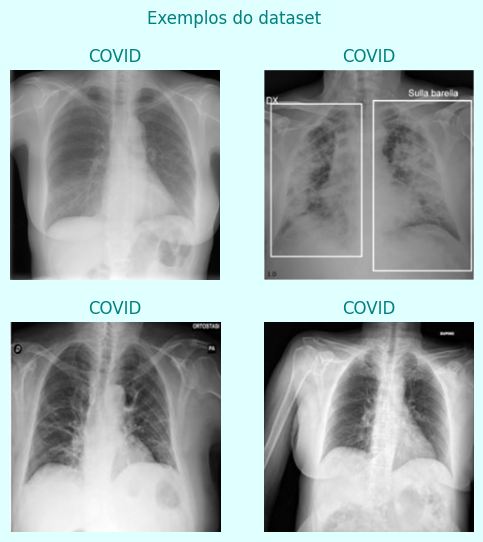

In [ ]:
# Mostra exemplos de imagens
plt.figure(figsize=(6,6), facecolor=COLOR_LIGHT)

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(classes[y[i]], color=COLOR_MAIN)
    plt.axis('off')

plt.suptitle("Exemplos do dataset", color=COLOR_MAIN)
plt.show()

**Insight**
- Agora conseguimos “ver” o problema.

**Interpretação**

**❓ Perguntas**

- Por que limpar dados?

- O que removemos?

- Impacto?

- Por que usar grayscale?

- Por que redimensionar?

## 6. EDA (Exploratory Data Analysis)

Count: [0 1], [1500 1500]


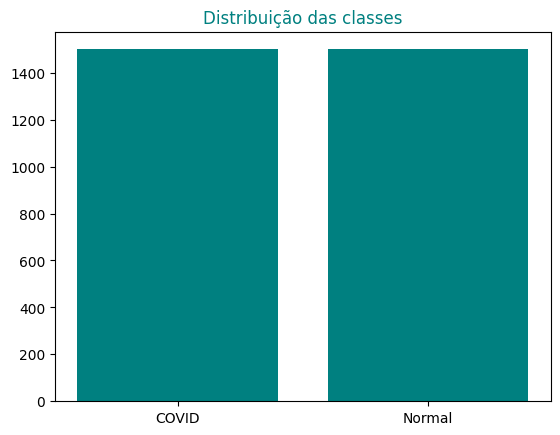

In [ ]:
# Converte listas em arrays
X = np.array(X)
y = np.array(y)

# Distribuição das classes
unique, counts = np.unique(y, return_counts=True)
print(f"Count: {unique}, {counts}")

plt.bar(classes, counts, color=COLOR_MAIN)
plt.title("Distribuição das classes", color=COLOR_MAIN)
plt.show()

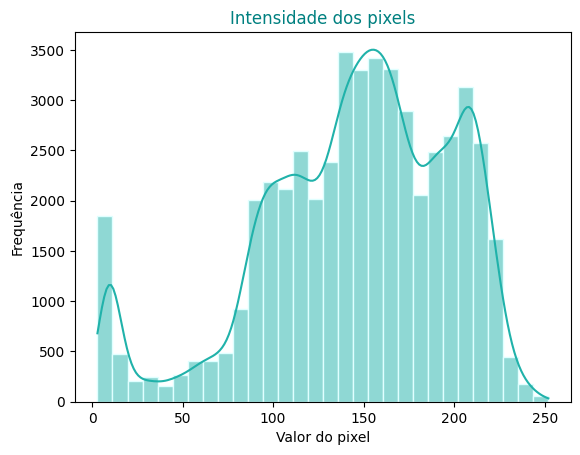

In [ ]:
# Histograma de intensidades de pixel
sns.histplot(X[0].flatten(), bins=30, color=COLOR_ACCENT, kde=True, edgecolor=COLOR_LIGHT)

plt.title("Intensidade dos pixels", color=COLOR_MAIN)
plt.xlabel("Valor do pixel")
plt.ylabel("Frequência")

plt.show()

**Insight**
- EDA em imagens foca em padrões visuais e qualidade.

**Interpretação**

**❓ Perguntas**

- O que analisamos?

- Por que olhar pixels?

- O dataset está balanceado?

## 7. Preparação

In [ ]:
# Normaliza valores dos pixels (0–255 → 0–1)
X = X / 255.0

# Verifica valores mínimo e máximo após normalização
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())

Valor mínimo: 0.0
Valor máximo: 1.0


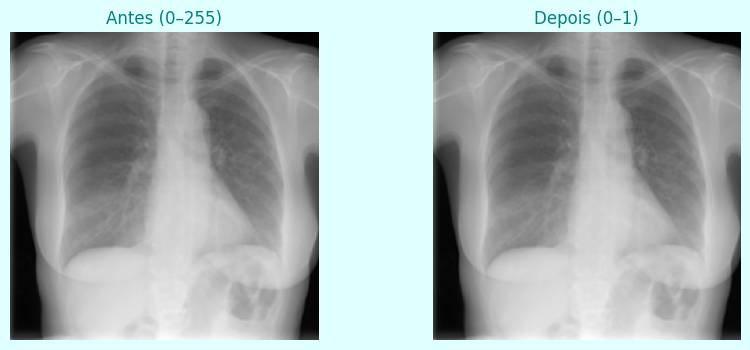

In [ ]:
# Visualização — comparação antes/depois
# Seleciona uma imagem original (antes da normalização)
img_original = (X[0] * 255).astype(np.uint8)  # reverte para visualização

# Imagem normalizada
img_normalizada = X[0]

plt.figure(figsize=(10,4), facecolor=COLOR_LIGHT)

# Antes
plt.subplot(1,2,1)
plt.imshow(img_original, cmap='gray')
plt.title("Antes (0–255)", color=COLOR_MAIN)
plt.axis('off')

# Depois
plt.subplot(1,2,2)
plt.imshow(img_normalizada, cmap='gray')
plt.title("Depois (0–1)", color=COLOR_MAIN)
plt.axis('off')

plt.show()

**Insight**
- A normalização não muda a imagem visualmente, mas muda como o modelo “enxerga” (vê) os dados.

**Interpretação**

**❓ Perguntas**

- Por que normalizar os dados?

- A imagem muda visualmente?

- O que muda então?

## 8. Classificador A

In [ ]:
# Converte cada imagem (224x224) em um vetor 1D (flatten)
# Exemplo: 224x224 → 50176 características
X_flat = X.reshape(len(X), -1)

print("Formato original:", X.shape)
print("Formato flatten:", X_flat.shape)

# Divide os dados em treino e teste (80% treino / 20% teste)
X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_flat,           # dados de entrada (features)
    y,                # labels (classes)
    test_size=0.2,    # 20% para teste
    random_state=42   # garante mesma divisão sempre
)

# Inicia contagem de tempo
start = time.time()

# Cria modelo de regressão logística
# max_iter aumenta número de iterações para garantir convergência
model_A = LogisticRegression(max_iter=1000)

# Treina o modelo com os dados de treino
model_A.fit(X_train_A, y_train)

# Faz previsões nos dados de teste
y_pred_A = model_A.predict(X_test_A)

# Calcula tempo total
time_A = time.time() - start

# Calcula acurácia (quantos acertos)
acc_A = accuracy_score(y_test, y_pred_A)

# Mostra resultados
print("Acurácia A:", acc_A)
print("Tempo A:", time_A)

Formato original: (3000, 224, 224)
Formato flatten: (3000, 50176)
Acurácia A: 0.8383333333333334
Tempo A: 134.23976826667786


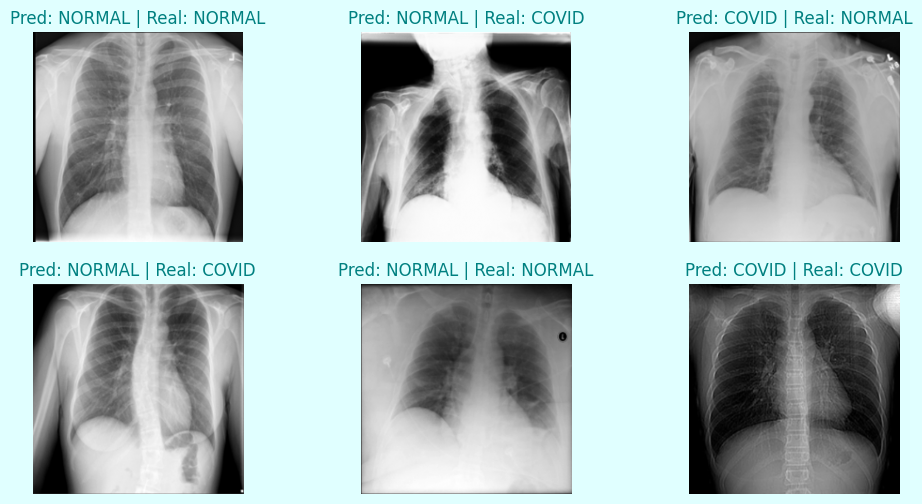

In [ ]:
# Mostra algumas previsões
labels_map = {0: "COVID", 1: "NORMAL"}

plt.figure(figsize=(12,6), facecolor=COLOR_LIGHT)

for i in range(6):

    plt.subplot(2,3,i+1)

    # Mostra imagem original
    plt.imshow(X_test_A[i].reshape(224,224), cmap='gray')

    # Usa labels_map
    plt.title(f"Pred: {labels_map[y_pred_A[i]]} | Real: {labels_map[y_test[i]]}", color=COLOR_MAIN)

    plt.axis('off')

plt.show()

**Insight**
Este modelo:
- Não entende estrutura da imagem
- Trata imagem como números
- Pode acertar, mas não aprende padrões médicos reais
- Mesmo acertando, o modelo não “entende” padrões visuais como bordas ou texturas.

**Interpretação**

Se a acurácia for:
- ~0.60 → aprendizado fraco
- ~0.70 → razoável
- ~0.80+ → surpreendente (mas cuidado)

**❓ Perguntas de reflexão**

- Por que este modelo tem limitações?

- O que significa “flatten”?

- O modelo entende imagens?

- Por que usar labels_map?

## 9. Transfer Learning

In [ ]:
# Carrega modelo VGG16 sem camada final
base_model = VGG16(weights='imagenet', include_top=False)

# Define tamanho do dataset
n_samples = len(X)

# Cria matriz para armazenar features
features_flat = np.zeros((n_samples, 7*7*512))

# Define tamanho do batch
batch_size = 16

# Processa imagens em lotes
for i in range(0, n_samples, batch_size):

    # Seleciona batch atual
    batch = X[i:i+batch_size]

    # Converte imagens grayscale para RGB (3 canais)
    batch_rgb = np.stack((batch,)*3, axis=-1)

    # Aplica pré-processamento específico da VGG16
    batch_rgb = preprocess_input(batch_rgb)

    # Extrai features com a rede
    features_batch = base_model.predict(batch_rgb, verbose=0)

    # Converte para vetor e salva diretamente
    features_flat[i:i+len(batch)] = features_batch.reshape(len(batch), -1)

    # Mostra progresso
    print(f"Processado: {i+len(batch)} / {n_samples}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Processado: 16 / 3000
Processado: 32 / 3000
Processado: 48 / 3000
Processado: 64 / 3000
Processado: 80 / 3000
Processado: 96 / 3000
Processado: 112 / 3000
Processado: 128 / 3000
Processado: 144 / 3000
Processado: 160 / 3000
Processado: 176 / 3000
Processado: 192 / 3000
Processado: 208 / 3000
Processado: 224 / 3000
Processado: 240 / 3000
Processado: 256 / 3000
Processado: 272 / 3000
Processado: 288 / 3000
Processado: 304 / 3000
Processado: 320 / 3000
Processado: 336 / 3000
Processado: 352 / 3000
Processado: 368 / 3000
Processado: 384 / 3000
Processado: 400 / 3000
Processado: 416 / 3000
Processado: 432 / 3000
Processado: 448 / 3000
Processado: 464 / 3000
Processado: 480 / 3000
Processado: 496 / 3000
Processado: 512 / 3000
Processado: 528 / 3000
Processado: 544 / 3000
Processado: 560 / 3000
Processado: 576 / 3000
Processado: 592 / 3000
Processado: 608 / 3000
Processado: 624 / 3000
Processado: 640 / 3000
Processado: 656 / 3000
Processado: 

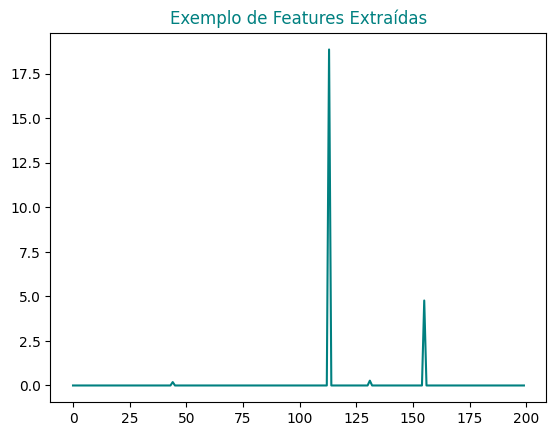

In [ ]:
# Visualização — features
plt.plot(features_flat[0][:200], color=COLOR_MAIN)
plt.title("Exemplo de Features Extraídas", color=COLOR_MAIN)
plt.show()

**Insight**
- Agora usamos uma representação mais rica da imagem.

**Interpretação**
- A VGG16 transforma pixels em padrões como bordas, formas e texturas.
- A maioria das features tem valor próximo de zero, enquanto algumas apresentam valores mais altos, indicando que certos padrões relevantes foram detectados na imagem.

**❓ Perguntas**

- O que são features?

- Por que a maioria das features é zero?

- O que representam os picos?

- Por que usar VGG16?

- Viu COVID antes?

## 10. Classificador B

In [ ]:
# Inicia tempo
start = time.time()

# Divide dados (mesma lógica do A)
X_train_B, X_test_B, _, _ = train_test_split(
    features_flat, y, test_size=0.2, random_state=42
)

# NORMALIZAÇÃO
# Cria objeto de escala
scaler = StandardScaler()

# Ajusta no treino e transforma
X_train_B = scaler.fit_transform(X_train_B)

# Aplica mesma transformação no teste
X_test_B = scaler.transform(X_test_B)

# MODELO
# Cria modelo
model_B = LogisticRegression(
    max_iter=2000,     # aumenta iterações → resolve convergência
    solver='lbfgs'     # padrão, com dados escalados funciona melhor
)

# Treina
model_B.fit(X_train_B, y_train)

# Faz previsões
y_pred_B = model_B.predict(X_test_B)

# Tempo
time_B = time.time() - start

# Acurácia
acc_B = accuracy_score(y_test, y_pred_B)

print("Acurácia B:", acc_B)
print("Tempo B:", time_B)

Acurácia B: 0.8716666666666667
Tempo B: 23.82911992073059


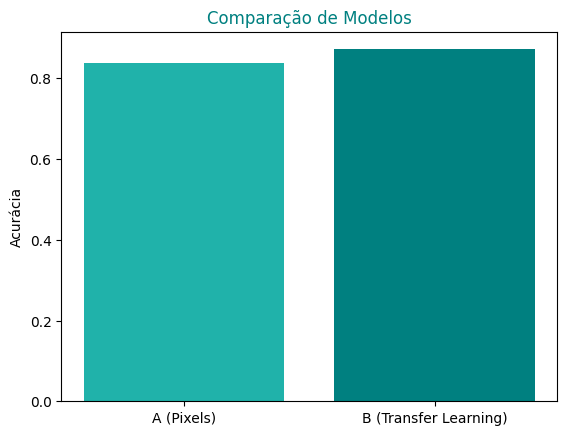

In [ ]:
# Comparação final
plt.bar(
    ["A (Pixels)", "B (Transfer Learning)"],
    [acc_A, acc_B],
    color=[COLOR_ACCENT, COLOR_MAIN]
)

plt.title("Comparação de Modelos", color=COLOR_MAIN)
plt.ylabel("Acurácia")

plt.show()

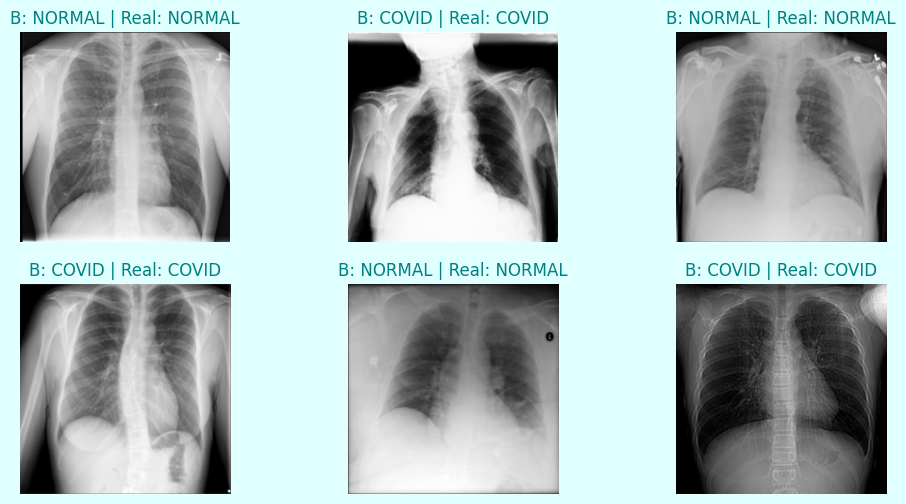

In [ ]:
# Visualizar previsões (TRANSFER LEARNING)
labels_map = {0: "COVID", 1: "NORMAL"}

plt.figure(figsize=(12,6), facecolor=COLOR_LIGHT)

for i in range(6):

    plt.subplot(2,3,i+1)

    # Mostra imagem
    plt.imshow(X_test_A[i].reshape(224,224), cmap='gray')

    # labels_map
    plt.title(f"B: {labels_map[y_pred_B[i]]} | Real: {labels_map[y_test[i]]}", color=COLOR_MAIN)
    plt.axis('off')

plt.show()

**Insight**

Agora o modelo:
- Usa padrões aprendidos
- Entende melhor imagens
- Generaliza melhor

**Interpretação**

Se B > A:
- Hipótese confirmada
- Transfer Learning funciona

**❓ Perguntas**

- Por que o modelo B é melhor?

- O modelo mudou?

- O que isso prova?

## 11. Conclusão Final

Os resultados obtidos demonstram que o Modelo B apresentou melhor desempenho em comparação com o Modelo A, tanto em termos de acurácia quanto de eficiência computacional.

Especificamente, o modelo A alcançou uma acurácia de 0.8383, enquanto o modelo B atingiu 0.8717, evidenciando uma melhoria no desempenho ao utilizar a abordagem adotada no Modelo B. Essa diferença indica que o modelo B conseguiu capturar padrões mais relevantes dos dados, resultando em previsões mais precisas.

Com base nesses resultados, há evidência empírica suficiente para concluir que o Modelo B é superior ao Modelo A neste contexto, pois combina maior acurácia com menor tempo de processamento.

Portanto, conclui-se que a escolha da abordagem impacta diretamente tanto a qualidade das previsões quanto a eficiência do modelo, sendo o Modelo B a opção mais adequada para este problema.